In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/ecommerce_customer_data_large.csv")
print(df.head())


   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        44605  2023-05-03 21:30:02             Home            177         1   
1        44605  2021-05-16 13:57:44      Electronics            174         3   
2        44605  2020-07-13 06:16:57            Books            413         1   
3        44605  2023-01-17 13:14:36      Electronics            396         3   
4        44605  2021-05-01 11:29:27            Books            259         4   

   Total Purchase Amount Payment Method  Customer Age  Returns Customer Name  \
0                   2427         PayPal            31      1.0   John Rivera   
1                   2448         PayPal            31      1.0   John Rivera   
2                   2345    Credit Card            31      1.0   John Rivera   
3                    937           Cash            31      0.0   John Rivera   
4                   2598         PayPal            31      1.0   John Rivera   

    Age  Gender  Churn  
0  31.0

In [3]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Returns"] = df["Returns"].fillna(0)
df = df.drop_duplicates()
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      1
Gender                   1
Churn                    1
dtype: int64


In [4]:
df["Revenue"] = df["Product Price"] * df["Quantity"]
snapshot_date = df["Purchase Date"].max() + pd.Timedelta(days=1)



In [5]:
rfm = df.groupby("Customer ID").agg({
    "Purchase Date": lambda x: (snapshot_date - x.max()).days,
    "Customer ID": "count",
    "Revenue": "sum",
    "Churn": "max"
})
rfm.columns = ["Recency", "Frequency", "Monetary", "Churn"]

print("\nRFM Table:")
print(rfm.head())



RFM Table:
             Recency  Frequency  Monetary  Churn
Customer ID                                     
1                289          3      5600    0.0
3                223          4      3613    0.0
4                442          5      4339    0.0
5                425          5      2263    0.0
6                141          9      9439    0.0


In [6]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4, 3, 2, 1]
)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1, 2, 3, 4]
)
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)
def customer_segment(score):

    if score.startswith("4"):
        return "High Value"

    elif score.startswith("3"):
        return "Loyal Customers"

    elif score.startswith("2"):
        return "Occasional Buyers"

    else:
        return "At Risk"

rfm["Segment"] = rfm["RFM_Score"].apply(customer_segment)


In [7]:
segment_summary = rfm.groupby("Segment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

print("\nSegment Summary:")
print(segment_summary)


Segment Summary:
                      Recency  Frequency     Monetary
Segment                                              
At Risk            545.972034   4.463840  3427.076743
High Value          33.610918   6.322518  4839.276683
Loyal Customers    115.667754   6.011479  4631.579963
Occasional Buyers  239.226846   5.594182  4269.354031


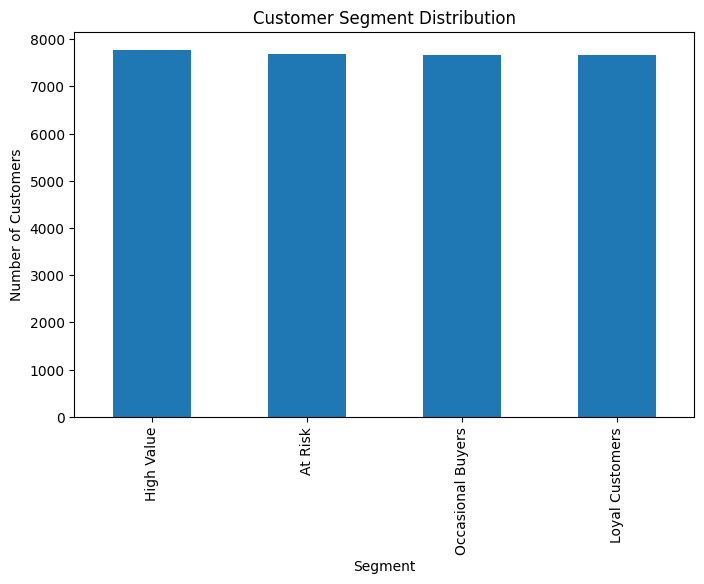

In [8]:
plt.figure(figsize=(8,5))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

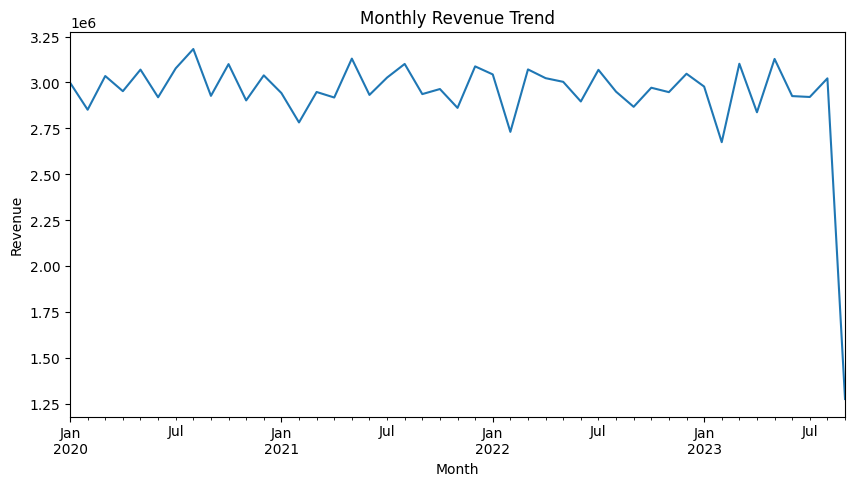

In [9]:
monthly_sales = df.groupby(
    df["Purchase Date"].dt.to_period("M")
)["Revenue"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

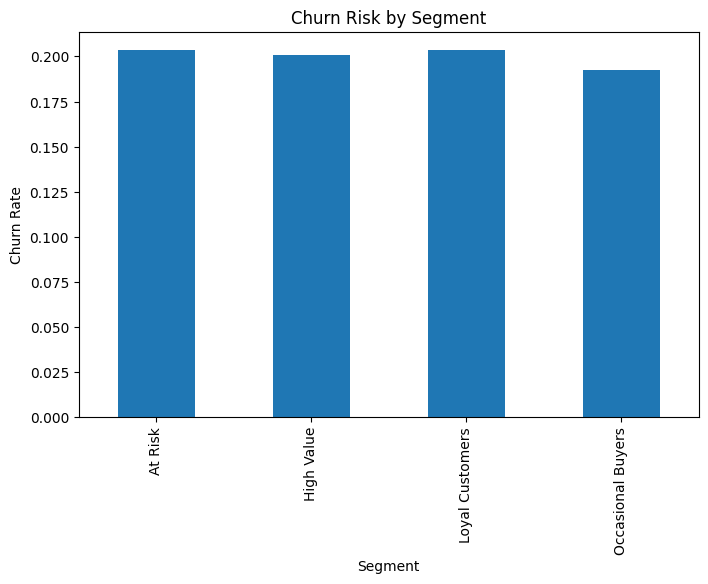

In [10]:
plt.figure(figsize=(8,5))

rfm.groupby("Segment")["Churn"].mean().plot(
    kind="bar"
)

plt.title("Churn Risk by Segment")
plt.ylabel("Churn Rate")

plt.show()

In [12]:
top_categories = df.groupby("Product Category")["Revenue"].sum().sort_values(ascending=False)

print("\nTop Categories:")
print(top_categories.head())


Top Categories:
Product Category
Clothing       33174263
Home           33149392
Books          32927457
Electronics    32917476
Name: Revenue, dtype: int64


In [13]:
retention = rfm.groupby("Segment")["Churn"].mean()

print("\nRetention / Churn Analysis:")
print(retention)


Retention / Churn Analysis:
Segment
At Risk              0.203460
High Value           0.200592
Loyal Customers      0.203496
Occasional Buyers    0.192408
Name: Churn, dtype: float64


In [14]:
print("\nActionable Recommendations")

recommendations = [
    "1. Launch loyalty rewards for high-value customers.",
    "2. Send personalized discounts to at-risk customers.",
    "3. Create bundled offers for popular products.",
    "4. Improve customer retention using follow-up emails.",
    "5. Run seasonal marketing campaigns during high-sales periods."
]

for rec in recommendations:
    print(rec)



Actionable Recommendations
1. Launch loyalty rewards for high-value customers.
2. Send personalized discounts to at-risk customers.
3. Create bundled offers for popular products.
4. Improve customer retention using follow-up emails.
5. Run seasonal marketing campaigns during high-sales periods.


In [15]:
rfm.to_csv("customer_segments.csv")

print("\nCustomer segmentation file saved successfully!")


Customer segmentation file saved successfully!
